## Analysis of battery
### GOALS
- Plot Power and Current Consumption
- Plot Self Heating of the battery
- Plot the energy of the battery and the current mode
- Plot Voltage Approximation
- Plot Power and Current generated by the solar panels
- Plot Power and Current of the battery

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import ListedColormap
import astropy.units as u

### Import data

In [7]:
bat_file = "../../results/data/battery.npy"
time_file = "../../results/data/times.npy"
mode_file = "../../results/data/modes.npy"
cons_file = "../../results/data/consumption.npy"
gen_file = "../../results/data/generation.npy"

with open(bat_file, "rb") as f:
    bat = np.load(f)
with open(time_file, "rb") as f:
    times = np.load(f)
with open(mode_file, "rb") as f:
    modes = np.load(f)
with open(cons_file, "rb") as f:
    cons = np.load(f)
with open(gen_file, "rb") as f:
    gen = np.load(f)

print(bat)
print(times)
print(modes)
print(cons)
print(gen)

simulation_time = (times[-1] * u.s).to(u.day)
print(simulation_time)

[124416.         124343.5        124271.         ... 124472.04879478
 124679.77398519 124617.27398519]
[0.000e+00 1.000e+01 2.000e+01 ... 4.318e+04 4.319e+04 4.320e+04]
[0. 1. 1. ... 0. 0. 0.]
[0.   7.25 7.25 ... 6.25 6.25 6.25]
[ 0.          0.          0.         ...  0.         27.02251904
  0.        ]
0.5 d


/tmp/ipykernel_8773/1557093102.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


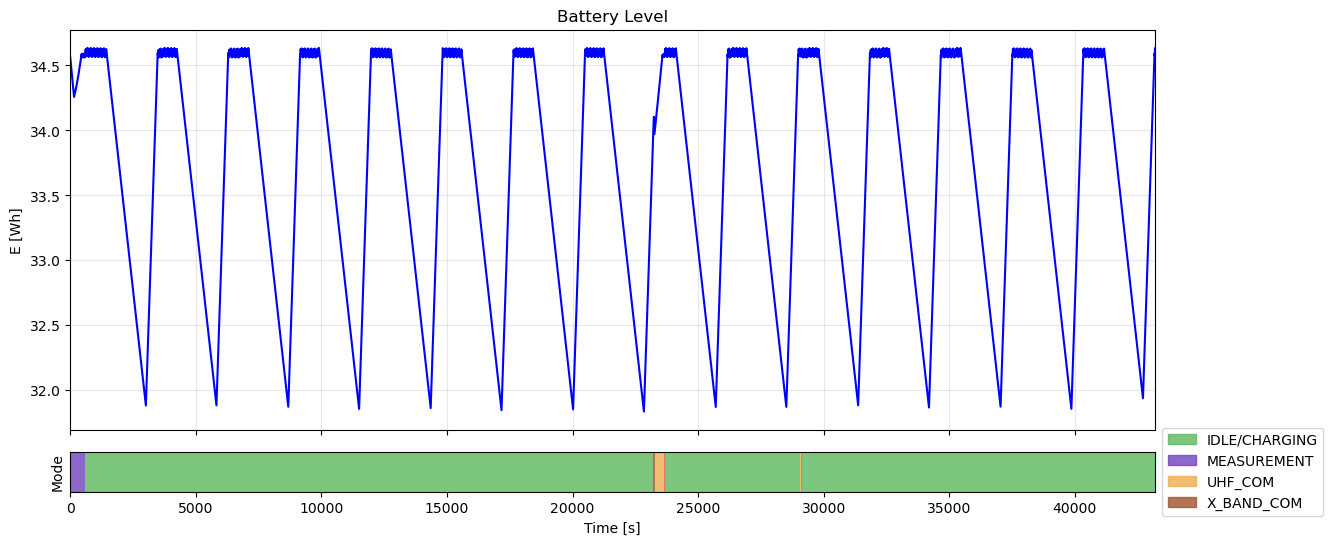

In [19]:
def plot_with_mode_indicator(times, values, ylabel, title, unit_label=''):
    """
    Plot values over time with mode indicator bar below.
    
    Parameters:
    - times: array of time points
    - values: array of values to plot
    - ylabel: label for y-axis
    - title: plot title
    - unit_label: optional unit label (e.g., '[Wh]')
    """
    # Mode colors and labels (always the same)
    mode_colors = {0: "#5cb85c", 1: "#6f42c1", 2: "#d9534f", 3: "#f0ad4e", 4: "#a0522d"}
    mode_labels = {0: "IDLE/CHARGING", 1: "MEASUREMENT", 2: "SAFE", 3: "UHF_COM", 4: "X_BAND_COM"}
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), 
                                   gridspec_kw={'height_ratios': [10, 1], 'hspace': 0.1})
    
    # Plot values on main axis
    ax1.plot(times, values, 'b-', linewidth=1.5)
    ax1.set_ylabel(f'{ylabel} {unit_label}' if unit_label else ylabel)
    ax1.set_title(title)
    ax1.grid(True, alpha=0.3)
    
    # Create mode indicator bar
    mode_array = modes.reshape(1, -1)
    colors_list = [mode_colors[i] for i in range(5)]
    cmap = ListedColormap(colors_list)
    
    im = ax2.imshow(mode_array, aspect='auto', extent=[times[0], times[-1], 0, 1], 
                    cmap=cmap, vmin=0, vmax=4, alpha=0.8)
    
    # Configure mode indicator axis
    ax2.set_xlim(times[0], times[-1])
    ax2.set_ylim(0, 1)
    ax2.set_xlabel('Time [s]')
    ax2.set_ylabel('Mode')
    ax2.set_yticks([])
    
    # Add legend
    unique_modes = np.unique(modes)
    legend_handles = [plt.Rectangle((0,0),1,1, color=mode_colors.get(mode, 'gray'), alpha=0.8) 
                     for mode in unique_modes]
    legend_labels_list = [mode_labels.get(mode, f'Mode {mode}') for mode in unique_modes]
    ax2.legend(legend_handles, legend_labels_list, loc='center left', bbox_to_anchor=(1, 0.5))
    
    # Align x-axes
    ax1.set_xlim(times[0], times[-1])
    ax1.set_xticklabels([])
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.savefig(f"{title.replace(' ', '_').lower()}.png", bbox_inches='tight', dpi=150)
    plt.show()

# Call the function for battery level
plot_with_mode_indicator(times, (bat * (u.W * u.s)).to(u.W * u.h).value, 
                         'E', 'Battery Level', '[Wh]')

/tmp/ipykernel_8773/1557093102.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


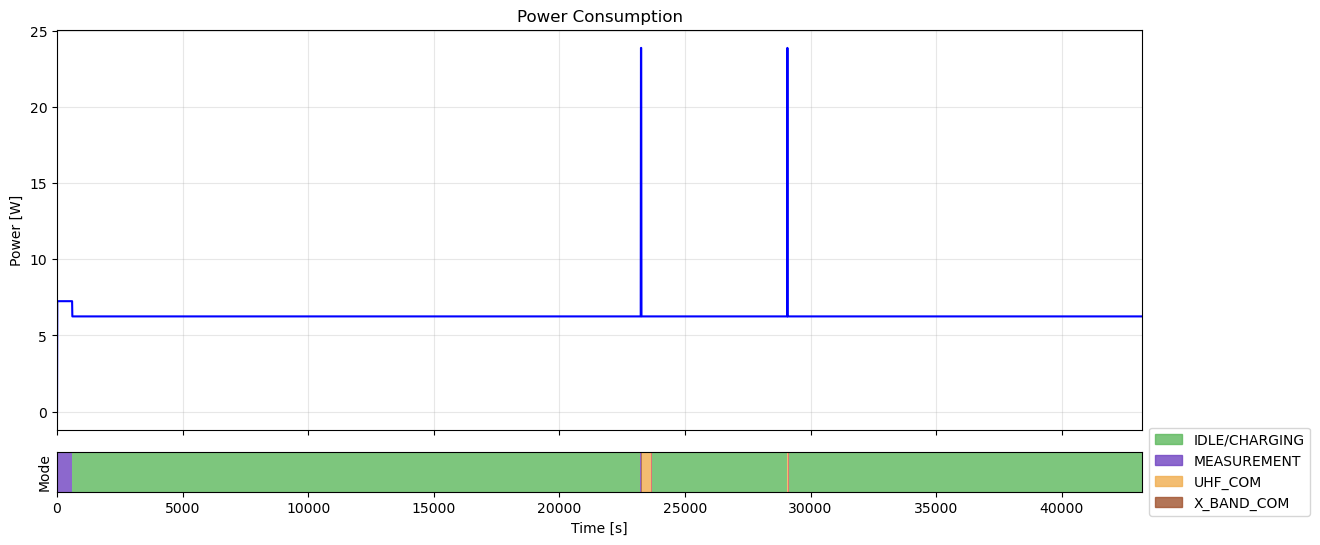

In [20]:
# Call the function for consumption
plot_with_mode_indicator(times, (cons * (u.W)).to(u.W).value, 
                         'Power', 'Power Consumption', '[W]')

/tmp/ipykernel_8773/1557093102.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


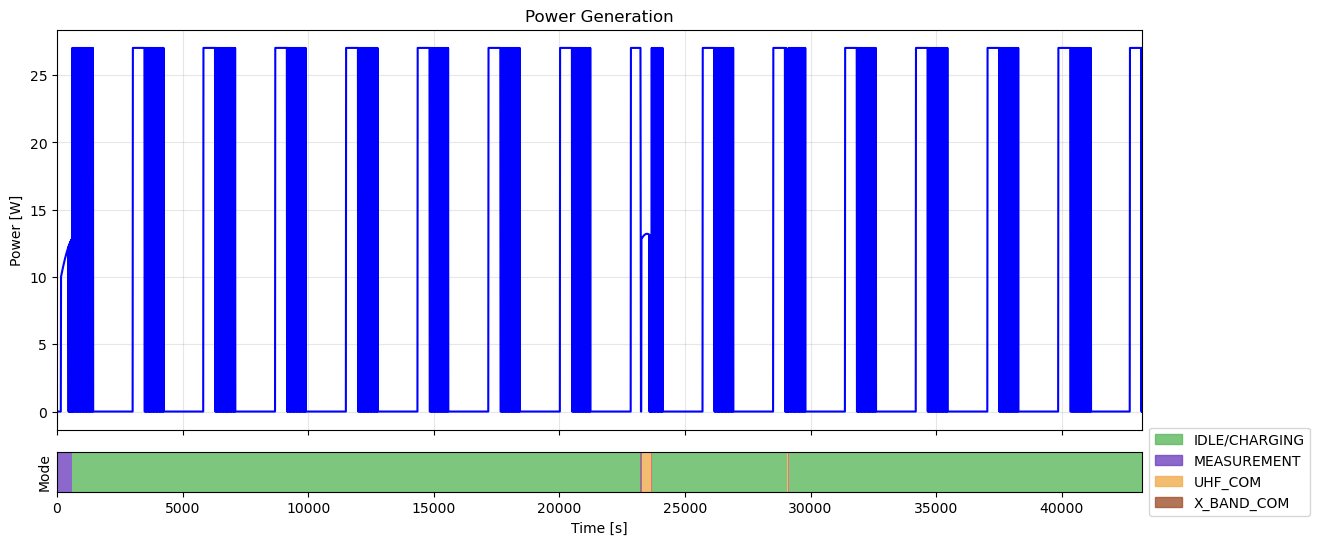

In [21]:
# call the function for generation
plot_with_mode_indicator(times, (gen * (u.W)).to(u.W).value, 
                         'Power', 'Power Generation', '[W]')